## Laufzeiten der Sortieralgorithmen

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import time 

#### Sortieralgorithmen mit quadratischer Laufzeit

In [2]:
def selection_sort(a):
    for i in range(len(a)-1):
        best = i
        best_val = a[i]
        for j in range(i+1,len(a)):
            if a[j] < best_val:
                best = j
                best_val = a[j]
        a[best],a[i] = a[i],a[best]

In [3]:
def bubble_sort(a):
    getauscht = True
    while getauscht:
        getauscht = False
        for i in range(len(a)-1):
            if a[i] > a[i+1]:
                a[i],a[i+1]=a[i+1],a[i]
                getauscht = True

In [73]:
def insertion_sort(a):
    for i in range(1,len(a)):
        x = a[i]
        j = i
        while j > 0 and a[j-1] > x:
            a[j] = a[j-1]
            j = j - 1
        a[j] = x
        

Verändere N und trage die entsprechenden Werte in die Listen in der nächsten Zeile ein.

In [12]:
N = 1                         # Anzahl zu sortierender Elemente in Tausend
anzahl_versuche = 100         # Anzahl Sortiervorgänge
summe = 0
for i in range(anzahl_versuche):
    a = [random.randint(-N*1000,N*1000) for _  in range(N*1000)] 
    start = time.perf_counter()
    selection_sort(a)
    end = time.perf_counter()
    summe = summe + (end-start)

print(f'{summe/anzahl_versuche:.3f}')


0.033


In [13]:
anzahl_elemente = [1, 2, 4, 8, 16, 32]                     # Anzahl zu sortierender Elemente in Tausend
selection = [0.016, 0.063, 0.254, 0.997, 4.103, 17.257]    # Zeit in Sekunden
# bubble = []
# insertion=[]

In [14]:
parms1 = np.polyfit(anzahl_elemente, selection, 2)          # Parameter für die quadratische selections_sort Funktion
# parms2 = np.polyfit(anzahl, bubble, 2)      # Parameter für die quadratische bubble_sort Funktion
# parms3 = np.polyfit(anzahl, insertion, 2)   # Parameter für die quadratische insertion_sort Funktion
parms1

array([ 0.01764757, -0.02727645,  0.05324792])

In [15]:
def f_sel(x):                               # die quadratische Funktion für Selection-sort
    return parms1[0]*x*x + parms1[1]*x + parms1[2]
# def f_bub(x):
#     return parms2[0]*x*x + parms2[1]*x + parms2[2]
# def f_ins(x):
#     return parms3[0]*x*x + parms3[1]*x + parms3[2]

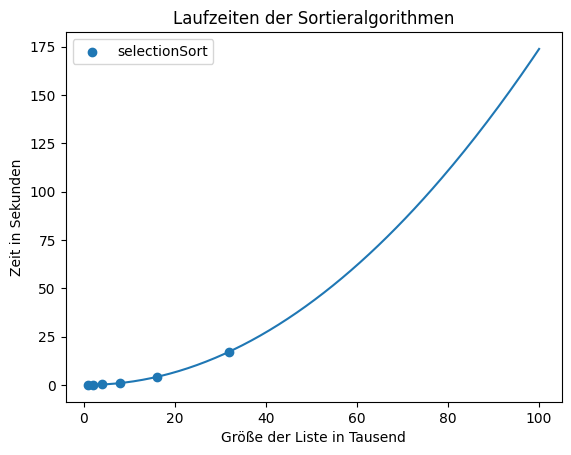

In [17]:
xmax = 100             # Bereich für die x-Achse
fig, ax = plt.subplots()
ax.scatter(anzahl_elemente,selection,label='selectionSort')
# ax.scatter(anzahl,bubble,label='bubbleSort')
# ax.scatter(anzahl,insertion,label='insertionSort')
ax.set_title('Laufzeiten der Sortieralgorithmen')
ax.set_xlabel('Größe der Liste in Tausend')
ax.set_ylabel('Zeit in Sekunden');
ax.legend();
xs = np.linspace(1,xmax,200)
ax.plot(xs,f_sel(xs),label='selectionSort');
# ax.plot(xs,f_bub(xs),label='bubbleSort');
# ax.plot(xs,f_ins(xs),label='insertionSort');
